# Day 6 — The Transformer Architecture
## 30 Days of AI: From NLP to LLMs

---

Every major language model in the world today — GPT-4, Claude, Gemini,
LLaMA, BERT — is a Transformer. Understanding this architecture deeply
is the single most important concept in this entire series.

Days 1 to 5 built up the motivation: bag-of-words ignores order,
n-grams have fixed tiny context windows, RNNs cannot parallelize,
LSTMs still struggle with very long-range dependencies. The Transformer
solves all of these at once.

Today we build every component from scratch — no deep learning
framework magic — so you understand exactly what is happening
inside the model.

---

### What You Will Learn Today

- Why Transformers were invented and what problems they replace
- Self-attention — built from scratch in NumPy
- Multi-head attention — built from scratch in PyTorch
- Positional encoding — sinusoidal and visualized
- The complete Transformer block
- Encoder vs Decoder and when to use each
- BERT vs GPT intuition with side-by-side comparison
- Why Transformers scale so much better than all previous models

### Goal by End of Day

Understand the Transformer architecture conceptually and implement
self-attention and multi-head attention from scratch.

In [26]:
## !pip install torch numpy matplotlib -q

import numpy as np
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
np.random.seed(42)

print('All libraries imported.')
print(f'PyTorch version : {torch.__version__}')

All libraries imported.
PyTorch version : 2.10.0+cpu


---

## Part 1 — Why Transformers Were Invented

Every architecture before Transformers had a hard ceiling on what
it could learn from language.

### The Problem Timeline

```
N-gram Models
  Problem 1 : Fixed context window — bigram sees 1 word, trigram sees 2
  Problem 2 : Data sparsity — unseen combinations collapse to zero
  Problem 3 : No generalization — 'cat' and 'feline' are unrelated

RNNs
  Problem 1 : Vanishing gradients — early tokens barely influence
              the hidden state after many steps
  Problem 2 : Sequential computation — step t waits for step t-1
              No parallelization possible during training
  Problem 3 : Poor long-range memory — position 1 is forgotten by 50

LSTMs
  Problem 1 : Gating helps gradients but training is still sequential
  Problem 2 : Long-range attention is still indirect
  Problem 3 : Information from far-back positions decays through gates

Transformers — Published 2017: 'Attention Is All You Need'
  Solution 1 : Replace recurrence with attention — fully parallel
  Solution 2 : Every token directly attends to every other token
  Solution 3 : Residual connections prevent vanishing gradients
  Solution 4 : Scale to billions of parameters on modern hardware
```

The core insight: you do not need to process a sequence step by step
to model it. You can process all positions at once if you use attention
to decide what each position should focus on.

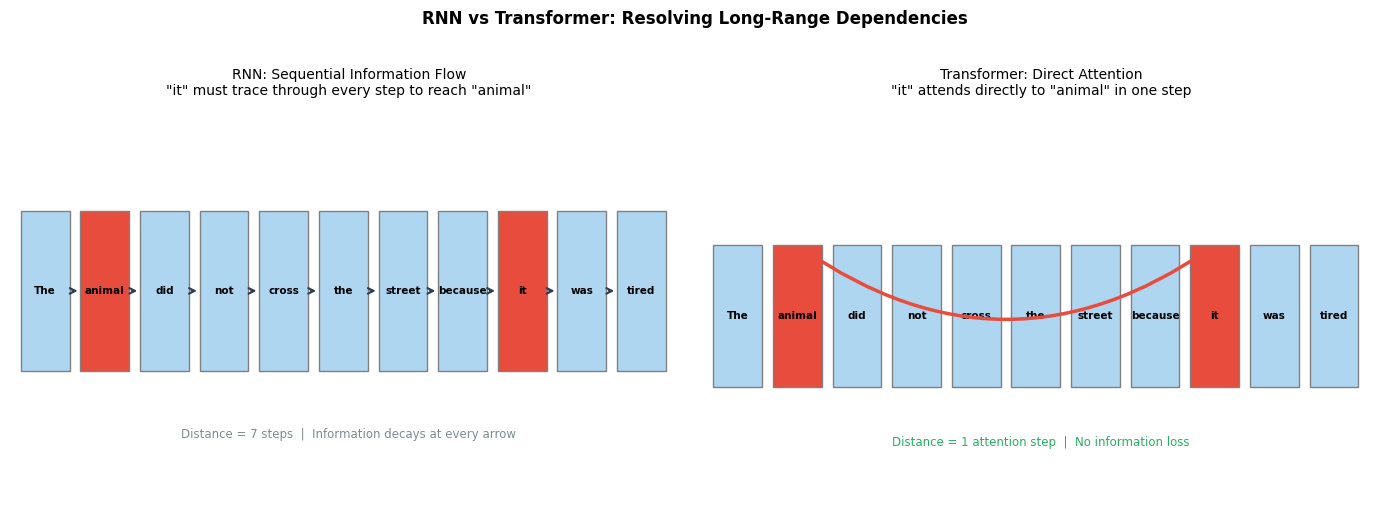

In [27]:
# Visualize the fundamental limitation of RNNs vs Transformers
# RNN: information flows through every intermediate step
# Transformer: every token directly attends to every other token

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tokens = ['The', 'animal', 'did', 'not', 'cross', 'the', 'street',
          'because', 'it', 'was', 'tired']
n = len(tokens)

# ── RNN: sequential path ──────────────────────────────────────────────
ax = axes[0]
ax.set_title('RNN: Sequential Information Flow\n"it" must trace through every step to reach "animal"',
             fontsize=10)
for i, tok in enumerate(tokens):
    color = '#E74C3C' if tok in ('animal', 'it') else '#AED6F1'
    ax.add_patch(plt.Rectangle((i * 1.1, 0), 0.9, 0.6,
                                color=color, ec='gray'))
    ax.text(i * 1.1 + 0.45, 0.3, tok, ha='center', va='center',
            fontsize=7.5, fontweight='bold')
    if i < n - 1:
        ax.annotate('', xy=((i+1)*1.1, 0.3),
                    xytext=(i*1.1+0.9, 0.3),
                    arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))
ax.text(n*1.1/2, -0.25,
        'Distance = 7 steps  |  Information decays at every arrow',
        ha='center', fontsize=8.5, color='#7F8C8D')
ax.set_xlim(-0.2, n * 1.1 + 0.2)
ax.set_ylim(-0.5, 1.0)
ax.axis('off')

# ── Transformer: direct attention ─────────────────────────────────────
ax = axes[1]
ax.set_title('Transformer: Direct Attention\n"it" attends directly to "animal" in one step',
             fontsize=10)
for i, tok in enumerate(tokens):
    color = '#E74C3C' if tok in ('animal', 'it') else '#AED6F1'
    ax.add_patch(plt.Rectangle((i * 1.1, 0), 0.9, 0.6,
                                color=color, ec='gray'))
    ax.text(i * 1.1 + 0.45, 0.3, tok, ha='center', va='center',
            fontsize=7.5, fontweight='bold')

animal_x = 1 * 1.1 + 0.45
it_x     = 8 * 1.1 + 0.45
ax.annotate('',
            xy=(animal_x, 0.6),
            xytext=(it_x, 0.6),
            arrowprops=dict(arrowstyle='<->', color='#E74C3C',
                            lw=2.5,
                            connectionstyle='arc3,rad=-0.35'))
ax.text(n*1.1/2, -0.25,
        'Distance = 1 attention step  |  No information loss',
        ha='center', fontsize=8.5, color='#27AE60')
ax.set_xlim(-0.2, n * 1.1 + 0.2)
ax.set_ylim(-0.5, 1.2)
ax.axis('off')

plt.suptitle('RNN vs Transformer: Resolving Long-Range Dependencies',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Part 2 — Self-Attention (The Core Mechanism)

Self-attention lets every token in a sequence look at every other
token and decide how much to attend to it when forming its own
output representation.

### The Three Vectors

For each token, three vectors are created from its embedding:

```
Query  (Q)  →  What information am I looking for?
Key    (K)  →  What information do I contain?
Value  (V)  →  What do I actually pass forward if selected?
```

Think of it as a soft search engine:
- Q is your search query
- K is the index of every document
- V is the content of every document
- Attention weights are the relevance scores

### The Formula

```
Attention(Q, K, V)  =  softmax( Q x K^T / sqrt(d_k) ) x V

Step 1  :  Q x K^T         → dot product gives raw attention scores
Step 2  :  / sqrt(d_k)     → scale to prevent softmax saturation
Step 3  :  softmax(...)    → normalize scores to sum to 1 per row
Step 4  :  x V             → weighted sum of value vectors
```

### Why Scale by sqrt(d_k)?

When d_k is large, dot products become large in magnitude. Large values
push the softmax into regions where gradients are near zero — the same
vanishing gradient problem we were trying to escape. Scaling by sqrt(d_k)
keeps the dot products in a stable range regardless of dimension size.

In [28]:
# Self-attention from scratch in NumPy — no frameworks
# This is the exact computation that runs inside every Transformer

def softmax(x, axis=-1):
    x_shifted = x - np.max(x, axis=axis, keepdims=True)  # numerical stability
    exp_x     = np.exp(x_shifted)
    return exp_x / exp_x.sum(axis=axis, keepdims=True)


def self_attention(Q, K, V, mask=None, verbose=False):
    """
    Scaled dot-product self-attention.

    Args:
        Q    : Query matrix  (seq_len, d_k)
        K    : Key matrix    (seq_len, d_k)
        V    : Value matrix  (seq_len, d_v)
        mask : Optional causal mask for decoder

    Returns:
        output          : (seq_len, d_v)
        attention_weights : (seq_len, seq_len)
    """
    d_k = Q.shape[-1]

    # Step 1: Raw attention scores
    scores = Q @ K.T                      # (seq_len, seq_len)

    # Step 2: Scale
    scores = scores / np.sqrt(d_k)

    # Step 3: Apply mask if provided (causal / decoder mask)
    if mask is not None:
        scores = scores + mask * (-1e9)   # mask future positions with -inf

    # Step 4: Softmax over key dimension
    attention_weights = softmax(scores, axis=-1)

    # Step 5: Weighted sum of values
    output = attention_weights @ V        # (seq_len, d_v)

    if verbose:
        print(f'Q shape              : {Q.shape}')
        print(f'K shape              : {K.shape}')
        print(f'V shape              : {V.shape}')
        print(f'Scores shape         : {scores.shape}')
        print(f'Attention weights    : {attention_weights.shape}')
        print(f'Output shape         : {output.shape}')

    return output, attention_weights


# Demonstrate with a small example
seq_len = 5
d_k     = 8
d_v     = 8

# In a real transformer, Q K V are learned projections of token embeddings
# Here we use random values for demonstration
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_v)

output, attn_weights = self_attention(Q, K, V, verbose=True)

print()
print('Attention Weight Matrix (rows = query tokens, cols = key tokens)')
print('Each row sums to 1.0')
print(np.round(attn_weights, 3))
print()
print('Row sums (should all be 1.0):', np.round(attn_weights.sum(axis=1), 6))

Q shape              : (5, 8)
K shape              : (5, 8)
V shape              : (5, 8)
Scores shape         : (5, 5)
Attention weights    : (5, 5)
Output shape         : (5, 8)

Attention Weight Matrix (rows = query tokens, cols = key tokens)
Each row sums to 1.0
[[0.143 0.288 0.081 0.428 0.061]
 [0.185 0.023 0.291 0.113 0.388]
 [0.037 0.046 0.138 0.043 0.736]
 [0.341 0.139 0.09  0.318 0.112]
 [0.39  0.197 0.266 0.11  0.036]]

Row sums (should all be 1.0): [1. 1. 1. 1. 1.]


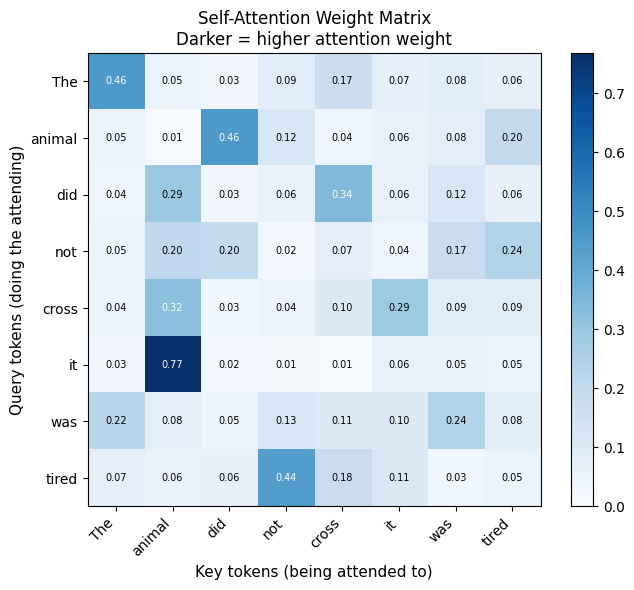


'it' (row 5) attention to 'animal' (col 1) : 0.7682
Higher weight means the model focuses more on that token.


In [29]:
# Visualize attention weights on a real sentence
# Simulate learned Q K V projections for a meaningful sentence

tokens = ['The', 'animal', 'did', 'not', 'cross', 'it', 'was', 'tired']
n      = len(tokens)
d_k    = 16

np.random.seed(7)
Q = np.random.randn(n, d_k)
K = np.random.randn(n, d_k)
V = np.random.randn(n, d_k)

# Manually bias attention so 'it' (index 5) attends to 'animal' (index 1)
# This simulates what a trained model learns
Q[5] = Q[5] * 0.3 + K[1] * 0.7   # 'it' query aligns with 'animal' key

_, attn = self_attention(Q, K, V)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(attn, cmap='Blues', vmin=0, vmax=attn.max())

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(tokens, fontsize=10)
ax.set_xlabel('Key tokens (being attended to)', fontsize=11)
ax.set_ylabel('Query tokens (doing the attending)', fontsize=11)
ax.set_title('Self-Attention Weight Matrix\nDarker = higher attention weight', fontsize=12)

for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{attn[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if attn[i,j] > 0.3 else 'black')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
print()
print(f"'it' (row 5) attention to 'animal' (col 1) : {attn[5,1]:.4f}")
print('Higher weight means the model focuses more on that token.')

---

## Part 3 — Multi-Head Attention

Single-head attention captures one type of relationship per layer.
But language has many simultaneous relationship types in every sentence:

```
Sentence: 'The bank by the river was steep'

Head 1 might learn  :  bank  → river    (semantic co-occurrence)
Head 2 might learn  :  bank  → steep    (modifier relationship)
Head 3 might learn  :  was   → steep    (subject-predicate link)
Head 4 might learn  :  The   → bank     (determiner-noun link)
```

Multi-head attention runs h independent attention operations in
parallel. Each head has its own learned Q, K, V projection matrices.
The outputs are concatenated and projected down:

```
MultiHead(Q, K, V)  =  Concat(head_1, ..., head_h)  x  W_O

where head_i  =  Attention(Q x W_Qi, K x W_Ki, V x W_Vi)
```

The total computation is similar to one large attention operation,
but the model learns richer, more diverse representations.

Common configurations:

```
BERT-base  :  12 heads,  d_model=768,   d_k=64 per head
BERT-large :  16 heads,  d_model=1024,  d_k=64 per head
GPT-2      :  12 heads,  d_model=768,   d_k=64 per head
GPT-3      :  96 heads,  d_model=12288, d_k=128 per head
```

In [30]:
# Multi-Head Attention implemented in PyTorch from scratch

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, \
            f'd_model ({d_model}) must be divisible by num_heads ({num_heads})'

        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads   # dimension per head

        # Learned projection matrices for Q, K, V and output
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def split_heads(self, x):
        """
        Reshape (batch, seq_len, d_model)
               to (batch, num_heads, seq_len, d_k)
        """
        B, S, _ = x.shape
        x = x.view(B, S, self.num_heads, self.d_k)
        return x.transpose(1, 2)   # (B, heads, S, d_k)

    def forward(self, x, mask=None):
        B, S, _ = x.shape

        # Project to Q, K, V then split into heads
        Q = self.split_heads(self.W_Q(x))   # (B, heads, S, d_k)
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))

        # Scaled dot-product attention for all heads simultaneously
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)   # (B, heads, S, S)
        attn_output  = attn_weights @ V             # (B, heads, S, d_k)

        # Merge heads: (B, heads, S, d_k) → (B, S, d_model)
        attn_output  = attn_output.transpose(1, 2).contiguous()
        attn_output  = attn_output.view(B, S, self.d_model)

        # Final output projection
        return self.W_O(attn_output), attn_weights


# Test the implementation
batch_size = 2
seq_len    = 10
d_model    = 64
num_heads  = 8

mha   = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
x     = torch.randn(batch_size, seq_len, d_model)
out, attn_w = mha(x)

print('Multi-Head Attention — Shape Check')
print('=' * 45)
print(f'Input shape          : {tuple(x.shape)}')
print(f'Output shape         : {tuple(out.shape)}')
print(f'Attention weights    : {tuple(attn_w.shape)}')
print(f'  Breakdown          : (batch={batch_size}, heads={num_heads},'
      f' seq={seq_len}, seq={seq_len})')
print()
print(f'Total parameters     : {sum(p.numel() for p in mha.parameters()):,}')
print(f'd_model={d_model}, num_heads={num_heads}, d_k per head={d_model//num_heads}')
print()
print('Each head attends across all', seq_len, 'positions independently.')
print('All heads run in parallel — no sequential bottleneck.')

Multi-Head Attention — Shape Check
Input shape          : (2, 10, 64)
Output shape         : (2, 10, 64)
Attention weights    : (2, 8, 10, 10)
  Breakdown          : (batch=2, heads=8, seq=10, seq=10)

Total parameters     : 16,384
d_model=64, num_heads=8, d_k per head=8

Each head attends across all 10 positions independently.
All heads run in parallel — no sequential bottleneck.


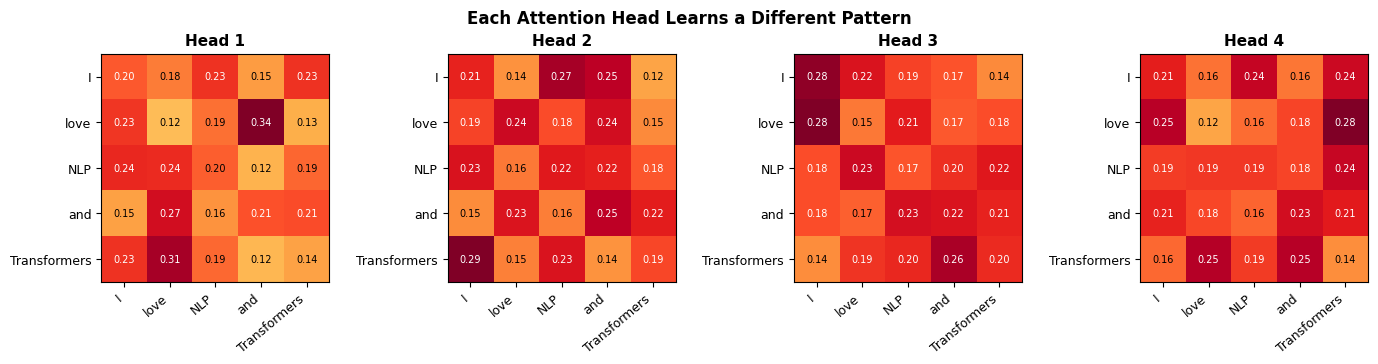

Notice: each head produces a different attention pattern on the same input.


In [31]:
# Show that different attention heads learn different patterns
# Each row in the heatmap is a different head's attention pattern

tokens_demo = ['I', 'love', 'NLP', 'and', 'Transformers']
n_tok       = len(tokens_demo)

d_model_demo = 20
n_heads_demo = 4

mha_demo   = MultiHeadAttention(d_model=d_model_demo, num_heads=n_heads_demo)
x_demo     = torch.randn(1, n_tok, d_model_demo)
_, attn_demo = mha_demo(x_demo)

fig, axes = plt.subplots(1, n_heads_demo, figsize=(14, 3.5))

for h in range(n_heads_demo):
    ax  = axes[h]
    mat = attn_demo[0, h].detach().numpy()
    im  = ax.imshow(mat, cmap='YlOrRd', vmin=0, vmax=mat.max())
    ax.set_title(f'Head {h+1}', fontsize=11, fontweight='bold')
    ax.set_xticks(range(n_tok))
    ax.set_yticks(range(n_tok))
    ax.set_xticklabels(tokens_demo, rotation=40, ha='right', fontsize=9)
    ax.set_yticklabels(tokens_demo, fontsize=9)
    for i in range(n_tok):
        for j in range(n_tok):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=7,
                    color='white' if mat[i,j] > mat.max()*0.6 else 'black')

plt.suptitle('Each Attention Head Learns a Different Pattern',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('Notice: each head produces a different attention pattern on the same input.')

---

## Part 4 — Positional Encoding

Self-attention is permutation-invariant. If you shuffle all tokens,
every token still attends to the same other tokens — just in different
order. The model cannot distinguish word order without help.

```
'dog bites man'   and   'man bites dog'
→ identical self-attention patterns without positional encoding
→ the model treats them as the same sentence
```

Positional encoding adds a position-dependent vector to each token
embedding before the first Transformer layer.

### Sinusoidal Positional Encoding (original Transformer)

```
PE(pos, 2i)    =  sin( pos / 10000^(2i / d_model) )
PE(pos, 2i+1)  =  cos( pos / 10000^(2i / d_model) )

pos  =  position of the token in the sequence
i    =  dimension index
```

Properties of sinusoidal encoding:
- Every position gets a unique vector
- Relative distance between positions can be expressed as a linear
  function — so the model can learn to use relative positions
- Works on sequences longer than those seen during training

Modern alternatives:
- Learned positional embeddings (BERT, GPT-2) — trainable lookup table
- RoPE (LLaMA, Mistral) — rotary embeddings, better length generalization
- ALiBi (MPT) — bias attention scores by relative distance directly

Positional Encoding Shape: (50, 64)
First 4 positions, first 8 dimensions:
[[ 0.      1.      0.      1.      0.      1.      0.      1.    ]
 [ 0.8415  0.5403  0.6816  0.7318  0.5332  0.846   0.4093  0.9124]
 [ 0.9093 -0.4161  0.9975  0.0709  0.9021  0.4315  0.7469  0.6649]
 [ 0.1411 -0.99    0.7783 -0.6279  0.9933 -0.116   0.9536  0.301 ]]


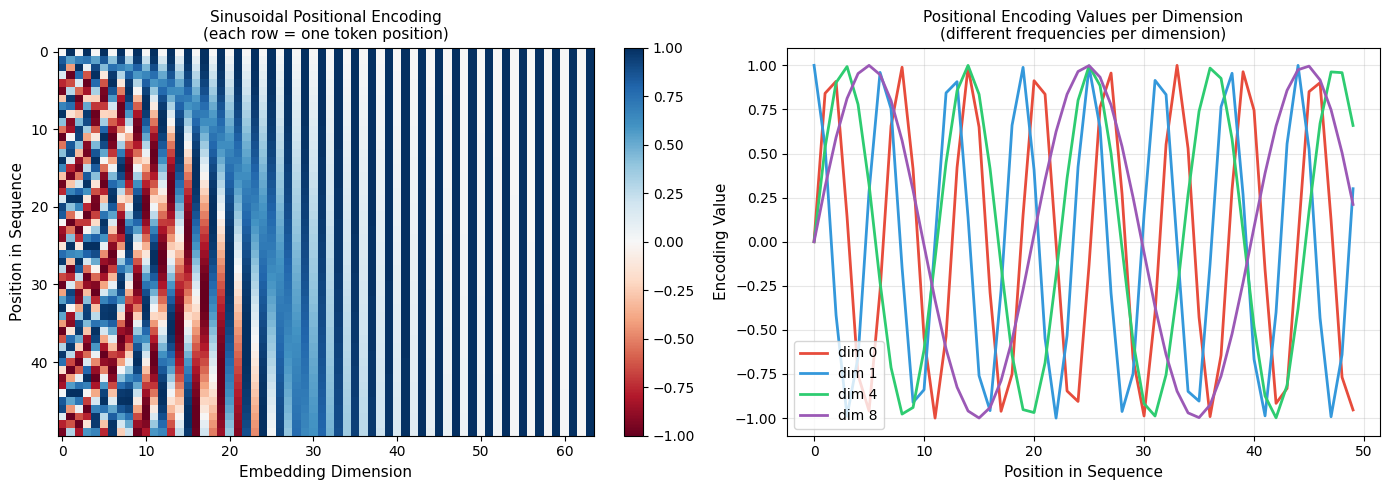


Each position gets a unique vector.
Low dimensions = high frequency (changes fast across positions)
High dimensions = low frequency (changes slowly across positions)


In [32]:
def sinusoidal_positional_encoding(seq_len, d_model):
    """
    Computes sinusoidal positional encoding.
    Returns tensor of shape (seq_len, d_model).
    """
    PE  = np.zeros((seq_len, d_model))
    pos = np.arange(seq_len)[:, np.newaxis]          # (seq_len, 1)
    i   = np.arange(0, d_model, 2)[np.newaxis, :]   # (1, d_model/2)

    div_term = np.power(10000, i / d_model)

    PE[:, 0::2] = np.sin(pos / div_term)   # even dimensions
    PE[:, 1::2] = np.cos(pos / div_term)   # odd dimensions

    return PE


seq_len = 50
d_model = 64
PE      = sinusoidal_positional_encoding(seq_len, d_model)

print('Positional Encoding Shape:', PE.shape)
print('First 4 positions, first 8 dimensions:')
print(np.round(PE[:4, :8], 4))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full heatmap
ax = axes[0]
im = ax.imshow(PE, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
ax.set_xlabel('Embedding Dimension', fontsize=11)
ax.set_ylabel('Position in Sequence', fontsize=11)
ax.set_title('Sinusoidal Positional Encoding\n(each row = one token position)', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046)

# Show first few dimensions as sine waves
ax = axes[1]
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
for dim_idx, color in zip([0, 1, 4, 8], colors):
    ax.plot(PE[:, dim_idx], label=f'dim {dim_idx}', color=color, linewidth=2)
ax.set_xlabel('Position in Sequence', fontsize=11)
ax.set_ylabel('Encoding Value', fontsize=11)
ax.set_title('Positional Encoding Values per Dimension\n(different frequencies per dimension)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()
print('Each position gets a unique vector.')
print('Low dimensions = high frequency (changes fast across positions)')
print('High dimensions = low frequency (changes slowly across positions)')

---

## Part 5 — The Complete Transformer Block

One Transformer block stacks four operations:

```
Input  x
  |
  +──────────────────────────────────+
  |                                  |
  |   Multi-Head Self-Attention      |
  |   (all tokens attend to all)     |
  |                                  |
  +──── Residual: x = x + Attn(x) ──+
  |
  +──── Layer Norm ─────────────────+
  |
  +──────────────────────────────────+
  |                                  |
  |   Feed-Forward Network           |
  |   Linear → ReLU/GELU → Linear   |
  |   Applied to each token alone    |
  |                                  |
  +──── Residual: x = x + FFN(x) ───+
  |
  +──── Layer Norm ─────────────────+
  |
Output  (same shape as input)
```

Stack N of these blocks to form the full model (BERT-base: 12 blocks,
GPT-2: 12 blocks, GPT-3: 96 blocks).

### Role of Each Component

```
Self-Attention     →  Communication between tokens
                       'What should I pay attention to?'

Feed-Forward Net   →  Computation within each token
                       'Now process what I have gathered'

Residual Connects  →  Gradient highway through the network
                       Enables training very deep models

Layer Norm         →  Stabilizes activation distributions
                       Speeds up convergence significantly
```

In [33]:
class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network."""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(
            self.dropout(F.gelu(self.linear1(x)))
        )


class TransformerBlock(nn.Module):
    """
    One complete Transformer block.
    Pre-LayerNorm variant (used in modern LLMs like GPT-2 onward).
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention  = MultiHeadAttention(d_model, num_heads)
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Sub-layer 1: Multi-head attention + residual + norm
        attn_out, attn_w = self.attention(self.norm1(x), mask)
        x = x + self.dropout(attn_out)        # residual connection

        # Sub-layer 2: Feed-forward + residual + norm
        x = x + self.dropout(self.ffn(self.norm2(x)))

        return x, attn_w


class TransformerEncoder(nn.Module):
    """Stack of N Transformer blocks (BERT-style encoder)."""
    def __init__(self, vocab_size, d_model, num_heads,
                 d_ff, num_layers, max_seq_len=512, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_seq_len, d_model)
        self.blocks    = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm      = nn.LayerNorm(d_model)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, token_ids, mask=None):
        B, S   = token_ids.shape
        pos    = torch.arange(S, device=token_ids.device).unsqueeze(0)
        x      = self.dropout(
            self.embedding(token_ids) + self.pos_embed(pos)
        )
        for block in self.blocks:
            x, _ = block(x, mask)
        return self.norm(x)


# Build a small BERT-like encoder and run a forward pass
model = TransformerEncoder(
    vocab_size  = 1000,
    d_model     = 64,
    num_heads   = 4,
    d_ff        = 256,
    num_layers  = 2,
    max_seq_len = 128
)

dummy_input = torch.randint(0, 1000, (2, 12))   # batch=2, seq_len=12
output      = model(dummy_input)

total_params = sum(p.numel() for p in model.parameters())

print('Transformer Encoder — Architecture Summary')
print('=' * 50)
print(f'Vocabulary size   : 1,000')
print(f'd_model           : 64')
print(f'Attention heads   : 4')
print(f'd_k per head      : {64 // 4}')
print(f'FFN hidden size   : 256  (4 x d_model)')
print(f'Number of layers  : 2')
print(f'Total parameters  : {total_params:,}')
print()
print(f'Input shape       : {tuple(dummy_input.shape)}')
print(f'Output shape      : {tuple(output.shape)}')
print()
print('Output shape is identical to input shape — each token')
print('now contains a rich contextual representation.')

Transformer Encoder — Architecture Summary
Vocabulary size   : 1,000
d_model           : 64
Attention heads   : 4
d_k per head      : 16
FFN hidden size   : 256  (4 x d_model)
Number of layers  : 2
Total parameters  : 171,776

Input shape       : (2, 12)
Output shape      : (2, 12, 64)

Output shape is identical to input shape — each token
now contains a rich contextual representation.


---

## Part 6 — Causal Masking for the Decoder

Encoder (BERT): every token attends to every other token.
This is bidirectional — perfect for understanding tasks.

Decoder (GPT): when generating token at position t, the model
must NOT see tokens at positions t+1, t+2, ... — those are the
future tokens it is trying to predict.

A **causal mask** (lower triangular matrix) blocks attention to
future positions by setting those scores to negative infinity
before softmax:

```
Mask for sequence length 5:

       pos0  pos1  pos2  pos3  pos4
pos0  [  1     0     0     0     0  ]
pos1  [  1     1     0     0     0  ]
pos2  [  1     1     1     0     0  ]
pos3  [  1     1     1     1     0  ]
pos4  [  1     1     1     1     1  ]

0 = blocked (set to -inf before softmax → attention weight ≈ 0)
1 = allowed
```

Causal Mask (lower triangular)
1 = can attend    0 = blocked (future)

[[1 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [1 1 1 1 0 0]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]


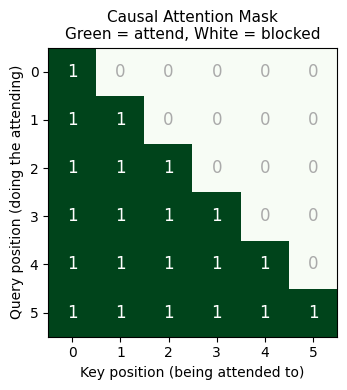

In [34]:
def make_causal_mask(seq_len):
    """
    Creates a causal mask: upper triangle is 0 (blocked),
    lower triangle + diagonal is 1 (allowed).
    """
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask.unsqueeze(0).unsqueeze(0)  # (1, 1, seq, seq) for broadcasting


seq_len  = 6
mask     = make_causal_mask(seq_len)

print('Causal Mask (lower triangular)')
print('=' * 40)
print('1 = can attend    0 = blocked (future)')
print()
print(mask.squeeze().int().numpy())

# Visualize the mask
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(mask.squeeze().numpy(), cmap='Greens', vmin=0, vmax=1)
ax.set_title('Causal Attention Mask\nGreen = attend, White = blocked', fontsize=11)
ax.set_xlabel('Key position (being attended to)', fontsize=10)
ax.set_ylabel('Query position (doing the attending)', fontsize=10)
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
for i in range(seq_len):
    for j in range(seq_len):
        val = int(mask[0,0,i,j].item())
        ax.text(j, i, str(val), ha='center', va='center', fontsize=12,
                color='white' if val == 1 else '#AAAAAA')
plt.tight_layout()
plt.show()

---

## Part 7 — Encoder vs Decoder vs Encoder-Decoder

The original Transformer had both encoder and decoder. Modern models
typically use one or the other.

```
ENCODER ONLY (BERT-style)
─────────────────────────────────────────────────
Attention type   :  Bidirectional
                    Every token sees every other token
Pre-training     :  Masked Language Modeling
                    Predict [MASK] from surrounding context
Best for         :  Classification, NER, QA, embeddings
Examples         :  BERT, RoBERTa, DeBERTa, ALBERT


DECODER ONLY (GPT-style)
─────────────────────────────────────────────────
Attention type   :  Causal (left-to-right only)
                    Each token sees only past tokens
Pre-training     :  Next Token Prediction
                    Predict the next word autoregressively
Best for         :  Text generation, coding, reasoning
Examples         :  GPT-2, GPT-3, GPT-4, Claude, LLaMA


ENCODER-DECODER (T5-style)
─────────────────────────────────────────────────
Attention type   :  Encoder = bidirectional
                    Decoder = causal + cross-attention to encoder
Pre-training     :  Span corruption / seq-to-seq objectives
Best for         :  Translation, summarization, seq-to-seq
Examples         :  T5, BART, mT5, PEGASUS
```

In [35]:
# Side-by-side comparison: BERT vs GPT architecture behavior

print('BERT vs GPT — Architecture Comparison')
print('=' * 65)

comparison = [
    ('Architecture',     'Encoder only',                    'Decoder only'),
    ('Attention',        'Bidirectional',                   'Causal (left-to-right)'),
    ('Pre-training',     'Masked Language Modeling',        'Next Token Prediction'),
    ('Input',            'Full sentence at once',           'Token by token'),
    ('Context',          'Both left and right context',     'Only left context'),
    ('Primary use',      'Understanding tasks',             'Generation tasks'),
    ('Classification',   'Add [CLS] head',                  'Prompt-based'),
    ('Generation',       'Not natural',                     'Native capability'),
    ('Example models',   'BERT, RoBERTa, DeBERTa',          'GPT-2/3/4, Claude, LLaMA'),
    ('Embedding use',    'Excellent sentence embeddings',   'Possible but less common'),
    ('Scaling trend',    'Diminishing returns past 1B',     'Still improving at 100B+'),
]

print(f'  {"Property":<22} {"BERT":<30} {"GPT"}')
print('  ' + '-' * 63)
for prop, bert_val, gpt_val in comparison:
    print(f'  {prop:<22} {bert_val:<30} {gpt_val}')

print()
print('Modern trend: Decoder-only models (GPT-style) have become')
print('dominant because they generalize to almost any task via prompting,')
print('without needing task-specific fine-tuning heads.')

BERT vs GPT — Architecture Comparison
  Property               BERT                           GPT
  ---------------------------------------------------------------
  Architecture           Encoder only                   Decoder only
  Attention              Bidirectional                  Causal (left-to-right)
  Pre-training           Masked Language Modeling       Next Token Prediction
  Input                  Full sentence at once          Token by token
  Context                Both left and right context    Only left context
  Primary use            Understanding tasks            Generation tasks
  Classification         Add [CLS] head                 Prompt-based
  Generation             Not natural                    Native capability
  Example models         BERT, RoBERTa, DeBERTa         GPT-2/3/4, Claude, LLaMA
  Embedding use          Excellent sentence embeddings  Possible but less common
  Scaling trend          Diminishing returns past 1B    Still improving at 100B+

Moder

---

## Part 8 — Why Transformers Scale So Well

No previous architecture scaled the way Transformers do. The reasons
are architectural and practical:

### Parallel Computation

RNNs process tokens sequentially — token 100 cannot be computed until
token 99 is done. Transformers compute all positions simultaneously.
This makes GPUs dramatically more efficient — instead of waiting,
every core is working on something useful.

### Attention Flexibility

The attention mechanism makes no assumptions about what is related to
what. It learns any relationship from data. This generality means
the same architecture works for text, images, audio, video, code,
protein sequences, and scientific data.

### Scaling Laws (Chinchilla / Kaplan et al.)

```
Loss decreases predictably as you scale:
  - Model parameters (N)
  - Training tokens  (D)
  - Compute budget   (C)

Optimal: for a given compute budget, scale N and D together.
Chinchilla (2022): 70B params + 1.4T tokens outperforms
                   175B params + 300B tokens (same compute)
```

### Emergent Capabilities

At sufficient scale, capabilities appear that were not present in
smaller models and were not explicitly trained for:

```
~1B  params  :  Coherent text generation
~10B params  :  Multi-step reasoning
~100B params :  Code generation, in-context learning
~1T+  params :  Complex reasoning, instruction following,
                 cross-domain transfer
```

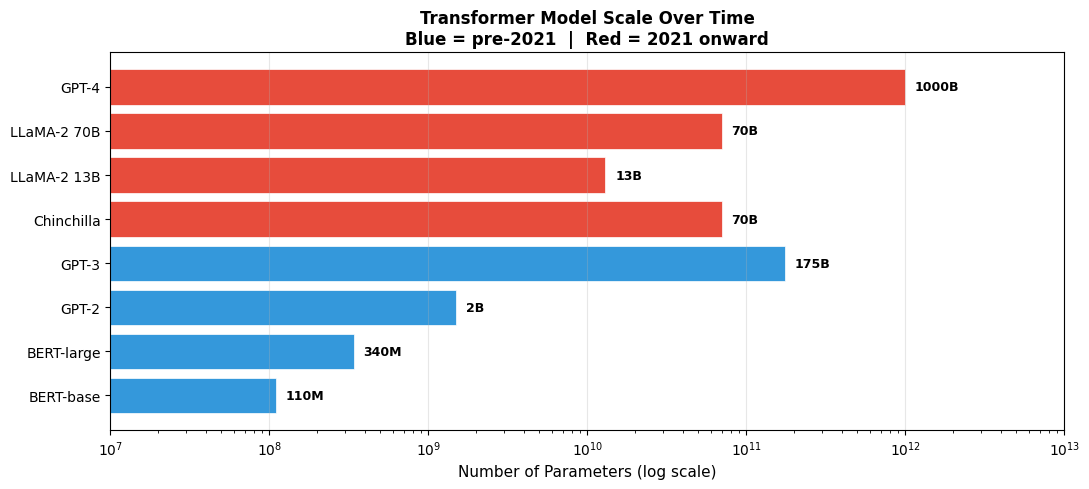

In [36]:
# Visualize how parameter count grows with model size
# and compare well-known models

models = [
    ('BERT-base',    110e6,   2017),
    ('BERT-large',   340e6,   2018),
    ('GPT-2',        1.5e9,   2019),
    ('GPT-3',        175e9,   2020),
    ('Chinchilla',   70e9,    2022),
    ('LLaMA-2 13B',  13e9,    2023),
    ('LLaMA-2 70B',  70e9,    2023),
    ('GPT-4',        1e12,    2023),
]

names  = [m[0] for m in models]
params = [m[1] for m in models]
years  = [m[2] for m in models]

fig, ax = plt.subplots(figsize=(11, 5))
colors  = ['#3498DB' if y <= 2020 else '#E74C3C' for y in years]
bars    = ax.barh(names, params, color=colors, edgecolor='white', linewidth=0.5)

ax.set_xscale('log')
ax.set_xlabel('Number of Parameters (log scale)', fontsize=11)
ax.set_title('Transformer Model Scale Over Time\nBlue = pre-2021  |  Red = 2021 onward',
             fontsize=12, fontweight='bold')

for bar, param in zip(bars, params):
    if param >= 1e9:
        label = f'{param/1e9:.0f}B'
    else:
        label = f'{param/1e6:.0f}M'
    ax.text(param * 1.15, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
ax.set_xlim(1e7, 1e13)
plt.tight_layout()
plt.show()

In [37]:
# Calculate parameter counts for different model sizes
# to understand what 'scaling' actually means in practice

def count_transformer_params(vocab_size, d_model, num_heads,
                              d_ff, num_layers, max_seq_len=512):
    """
    Estimates parameter count for a decoder-only Transformer.
    """
    # Token + position embeddings
    embed_params = vocab_size * d_model + max_seq_len * d_model

    # Per layer: attention (4 matrices) + FFN (2 matrices) + 2 layer norms
    attn_params    = 4 * d_model * d_model           # W_Q, W_K, W_V, W_O
    ffn_params     = 2 * d_model * d_ff              # up + down projection
    norm_params    = 4 * d_model                     # 2 norms x (weight + bias)
    per_layer      = attn_params + ffn_params + norm_params

    total = embed_params + num_layers * per_layer
    return total


configs = [
    ('Tiny  (demo)',     1000,   64,   4,   256,   2),
    ('Small (GPT-2 sm)', 50257, 768,  12,  3072,  12),
    ('Medium (GPT-2 md)',50257, 1024, 16,  4096,  24),
    ('Large  (GPT-2 lg)',50257, 1280, 20,  5120,  36),
    ('BERT-base',        30522, 768,  12,  3072,  12),
    ('BERT-large',       30522, 1024, 16,  4096,  24),
]

print('Transformer Parameter Count Estimates')
print('=' * 65)
print(f'  {"Model":<22} {"d_model":>8} {"Layers":>7} {"Parameters":>15}')
print('  ' + '-' * 55)

for name, vocab, d_model, heads, d_ff, layers in configs:
    params = count_transformer_params(vocab, d_model, heads, d_ff, layers)
    if params >= 1e9:
        param_str = f'{params/1e9:.2f}B'
    else:
        param_str = f'{params/1e6:.1f}M'
    print(f'  {name:<22} {d_model:>8} {layers:>7} {param_str:>15}')

Transformer Parameter Count Estimates
  Model                   d_model  Layers      Parameters
  -------------------------------------------------------
  Tiny  (demo)                 64       2            0.2M
  Small (GPT-2 sm)            768      12          124.0M
  Medium (GPT-2 md)          1024      24          354.1M
  Large  (GPT-2 lg)          1280      36          773.0M
  BERT-base                   768      12          108.8M
  BERT-large                 1024      24          333.9M


---

## Day 6 Summary

| Component | What It Does | Why It Matters |
|---|---|---|
| **Self-Attention** | Every token attends to every other token | Captures long-range dependencies in one step |
| **Scaled Dot-Product** | Q x K^T / sqrt(d_k) | Prevents softmax saturation with large dimensions |
| **Multi-Head Attention** | h parallel attention heads | Each head learns different relationship types |
| **Positional Encoding** | Sinusoidal or learned position vectors | Gives the model sense of word order |
| **Feed-Forward Network** | Two linear layers per token | Independent computation after attention mixing |
| **Residual Connections** | x = x + sublayer(x) | Gradient highway, enables very deep models |
| **Layer Normalization** | Normalize across feature dimension | Stabilizes training, speeds convergence |
| **Causal Mask** | Block future positions | Required for autoregressive text generation |
| **Encoder** | Bidirectional attention | Best for understanding tasks (BERT) |
| **Decoder** | Causal attention | Best for generation tasks (GPT, Claude) |



*30 Days of AI — Day 6 of 30 | The Transformer Architecture*